In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# tells jupyter notebook to display the plots in the notebook itself
%matplotlib inline
import seaborn as sns

df = pd.read_csv("../diabetes+130-us+hospitals+for+years+1999-2008/diabetic_data.csv")

In [3]:
# drop the columns that are not useful for our analysis

# encounter_id and patient_nbr are unique identifiers for each encounter and patient, respectively. 
# ML algorithms do not need these identifiers to learn patterns in the data, and they can actually introduce noise and lead to overfitting.
df.drop(columns=["encounter_id", "patient_nbr", "payer_code", "medical_specialty", "weight"], inplace=True)

In [4]:
# write me a function that will search through rows of df. For an inputted feature, if there is a missing value or question mark, delete that row.
def drop_missing_values(df, feature):
    df = df[df[feature] != "?"]
    df = df.dropna(subset=[feature])
    return df

df = drop_missing_values(df, "race")
df = drop_missing_values(df, "gender")
df = drop_missing_values(df, "diag_1")
df = drop_missing_values(df, "diag_2")
df = drop_missing_values(df, "diag_3")

In [5]:
# now for each feature currently in df, give me the number of missing data
for column in df.columns:
    missing_count = df[column].isna().sum() + (df[column] == "?").sum()
    print(f"Column: {column}, Missing Values: {missing_count}")

Column: race, Missing Values: 0
Column: gender, Missing Values: 0
Column: age, Missing Values: 0
Column: admission_type_id, Missing Values: 0
Column: discharge_disposition_id, Missing Values: 0
Column: admission_source_id, Missing Values: 0
Column: time_in_hospital, Missing Values: 0
Column: num_lab_procedures, Missing Values: 0
Column: num_procedures, Missing Values: 0
Column: num_medications, Missing Values: 0
Column: number_outpatient, Missing Values: 0
Column: number_emergency, Missing Values: 0
Column: number_inpatient, Missing Values: 0
Column: diag_1, Missing Values: 0
Column: diag_2, Missing Values: 0
Column: diag_3, Missing Values: 0
Column: number_diagnoses, Missing Values: 0
Column: max_glu_serum, Missing Values: 92845
Column: A1Cresult, Missing Values: 81860
Column: metformin, Missing Values: 0
Column: repaglinide, Missing Values: 0
Column: nateglinide, Missing Values: 0
Column: chlorpropamide, Missing Values: 0
Column: glimepiride, Missing Values: 0
Column: acetohexamide, 

In [6]:
df.columns

Index(['race', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='str')

In [7]:
# readmitted as 3 types. I need to convert this column so that it can be run as a classification problem.
def convert_readmitted(df):
    df["readmitted"] = df["readmitted"].map({"<30": 1, ">30": 1, "NO": 0})
    return df
df = convert_readmitted(df)

In [8]:
df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,1
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,0
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,0
5,Caucasian,Male,[50-60),2,1,2,3,31,6,16,...,No,Steady,No,No,No,No,No,No,Yes,1


In [9]:
# write me a function that will do one-hot encoding on a single feature and return the new dataframe with the one-hot encoded feature
def one_hot_encode(df, feature):
    if feature in df.columns:
        one_hot = pd.get_dummies(df[feature], prefix=feature)
        df = df.drop(feature, axis=1)
        df = df.join(one_hot)
    elif not any(col.startswith(f"{feature}_") for col in df.columns):
        raise KeyError(f"Feature '{feature}' not found in dataframe.")
    return df

df = one_hot_encode(df, "race")
df = one_hot_encode(df, "gender")
df = one_hot_encode(df, "age")
df = one_hot_encode(df, "admission_type_id")
df = one_hot_encode(df, "discharge_disposition_id")
df = one_hot_encode(df, "admission_source_id")
df = one_hot_encode(df, "diag_1")
df = one_hot_encode(df, "diag_2")
df = one_hot_encode(df, "diag_3")
df = one_hot_encode(df, "max_glu_serum")
df = one_hot_encode(df, "A1Cresult")

# give me a function that will do one-hot encoding on the diabetes medications and return the new dataframe with the one-hot encoded features
def one_hot_encode_diabetes_medications(df):
    diabetes_medications = [
    'metformin', 'repaglinide',
       'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
       'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
       'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
       'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
       'glipizide-metformin', 'glimepiride-pioglitazone',
       'metformin-rosiglitazone', 'metformin-pioglitazone', 'change',
       'diabetesMed'
    ]
    
    for feature in diabetes_medications:
        df = one_hot_encode(df, feature)
    
    return df

df = one_hot_encode_diabetes_medications(df)
df.head()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted,race_AfricanAmerican,...,glipizide-metformin_Steady,glimepiride-pioglitazone_No,glimepiride-pioglitazone_Steady,metformin-rosiglitazone_No,metformin-pioglitazone_No,metformin-pioglitazone_Steady,change_Ch,change_No,diabetesMed_No,diabetesMed_Yes
1,3,59,0,18,0,0,0,9,1,False,...,False,True,False,True,True,False,True,False,False,True
2,2,11,5,13,2,0,1,6,0,True,...,False,True,False,True,True,False,False,True,False,True
3,2,44,1,16,0,0,0,7,0,False,...,False,True,False,True,True,False,True,False,False,True
4,1,51,0,8,0,0,0,5,0,False,...,False,True,False,True,True,False,True,False,False,True
5,3,31,6,16,0,0,0,9,1,False,...,False,True,False,True,True,False,False,True,False,True


In [10]:
# List columns that are not numeric
non_numeric_cols = df.select_dtypes(exclude=[np.number, bool]).columns.tolist()
print("Non-numeric columns:", non_numeric_cols)

# Show unique values for each non-numeric column
for col in non_numeric_cols:
    print(f"Column: {col}, Unique values: {df[col].unique()[:10]}")

Non-numeric columns: []


In [11]:
# run logistic regression on the data to predict readmission
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
X = df.drop("readmitted", axis=1)
y = df["readmitted"]
# i want to the feature of the exact value causing the value error

# make this into train validation test split instead of just train test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


In [13]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_val)

print("Validation Set Performance:")
print(classification_report(y_val, y_pred))
print(confusion_matrix(y_val, y_pred))
from sklearn.metrics import roc_auc_score
y_pred_proba = logreg.predict_proba(X_val)[:, 1]
roc_auc = roc_auc_score(y_val, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

Validation Set Performance:
              precision    recall  f1-score   support

           0       0.64      0.73      0.68      7841
           1       0.64      0.53      0.58      6867

    accuracy                           0.64     14708
   macro avg       0.64      0.63      0.63     14708
weighted avg       0.64      0.64      0.64     14708

[[5741 2100]
 [3195 3672]]
ROC-AUC Score: 0.6924


/Users/jimmyle25/Desktop/Patient-Readmission/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Top 20 Most Important Features (Logistic Regression):
                          feature  importance
44    discharge_disposition_id_11    7.659724
47    discharge_disposition_id_14    2.402235
48    discharge_disposition_id_15    1.880695
59    discharge_disposition_id_28    1.520394
367                    diag_1_443    1.340339
189                 diag_1_250.41    1.229572
149                    diag_1_218    1.188779
226                    diag_1_282    1.152703
1215                   diag_2_648    1.091523
46    discharge_disposition_id_13    1.089540
74         admission_source_id_20    1.034838
784                    diag_1_V58    1.021762
234                    diag_1_290    0.977543
41     discharge_disposition_id_8    0.961007
54    discharge_disposition_id_22    0.948864
535                    diag_1_654    0.905001
446                    diag_1_540    0.900094
139                    diag_1_205    0.881617
444                    diag_1_537    0.881062
1631                diag_3

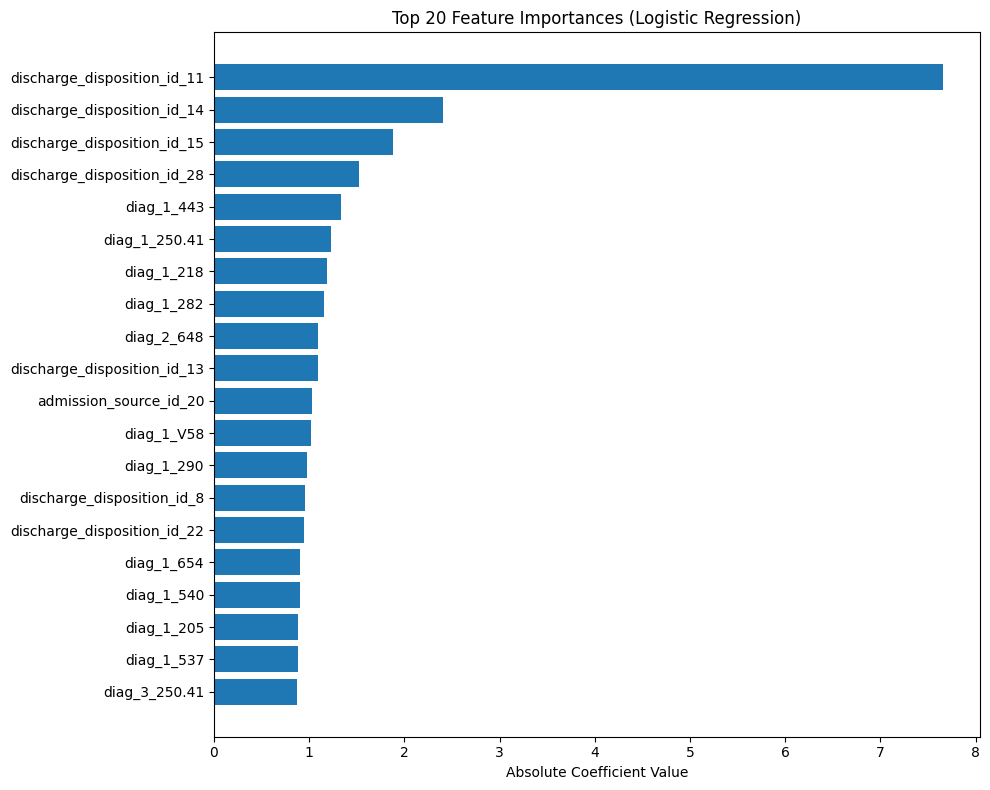

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names
feature_names = X_train.columns

# Get absolute values of coefficients (importance)
importance = np.abs(logreg.coef_[0])

# Create a DataFrame for easy viewing
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values(by='importance', ascending=False)

print("Top 20 Most Important Features (Logistic Regression):")
print(feature_importance.head(20))

# Plot top 20 features
top20 = feature_importance.head(20)
plt.figure(figsize=(10, 8))
plt.barh(top20['feature'][::-1], top20['importance'][::-1])
plt.xlabel('Absolute Coefficient Value')
plt.title('Top 20 Feature Importances (Logistic Regression)')
plt.tight_layout()
plt.show()
